In [1]:
# %% [markdown]
# # Cross-evaluation notebook (A/B/C)

# %%
from pathlib import Path
import os, json, math, numpy as np, pandas as pd
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# ---------- cohorts ----------
COHORTS = ["A", "B", "C"]

# ---------- point these to your saved datasets ----------
PKL_MAP = {
    "A": "/home/rafsan/Documents/Data/BIS/A_data_10_sec_1000.pkl",   # <<< EDIT
    "B": "/home/rafsan/Documents/Data/BIS/B_data_10_sec_1000.pkl",   # <<< EDIT
    "C": "/home/rafsan/Documents/Data/BIS/C_data_10_sec_1000.pkl",   # <<< EDIT
}

# ---------- project folders (same structure you used while training) ----------
ROOT        = Path("project")
DIR_MODELS  = ROOT / "models"
DIR_SPLITS  = ROOT / "splits"
DIR_CROSS   = ROOT / "cross"
DIR_FIGS    = ROOT / "figures"
for d in [ROOT, DIR_MODELS, DIR_SPLITS, DIR_CROSS, DIR_FIGS]:
    d.mkdir(parents=True, exist_ok=True)

# ---------- reproducibility ----------
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [6]:
from pathlib import Path
import os, json, math, numpy as np, pandas as pd
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt


In [7]:
# %% [markdown]
# ## 1) Model definition (paste/import your classes)

# %%
# ---- paste your model classes here OR import them ----
# from my_models import LightUNet_SE_ConvLSTM
class SEBlock1D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c, t = x.size()
        y = self.pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1)
        return x * y.expand_as(x)

class ConvSEBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, padding=1, dropout_prob=0.2):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size=kernel_size, padding=padding),
            nn.BatchNorm1d(out_ch, momentum=0.05),
            nn.ReLU(inplace=True),
            nn.Conv1d(out_ch, out_ch, kernel_size=kernel_size, padding=padding),
            nn.BatchNorm1d(out_ch, momentum=0.05),
            nn.ReLU(inplace=True)
        )
        self.se = SEBlock1D(out_ch)
        self.dropout = nn.Dropout(p=dropout_prob)
    def forward(self, x):
        x = self.conv(x)
        x = self.se(x)
        return self.dropout(x)

class TemporalConvMemory(nn.Module):
    def __init__(self, channels, kernel_size=5):
        super().__init__()
        self.depthwise = nn.Conv1d(channels, channels, kernel_size=kernel_size,
                                   padding=kernel_size // 2, groups=channels)
        self.pointwise = nn.Conv1d(channels, channels, kernel_size=1)
    def forward(self, x):
        mem = torch.relu(self.depthwise(x))
        mem = self.pointwise(mem)
        return mem + x

class LightUNet_SE_ConvLSTM(nn.Module):
    def __init__(self, input_channels=1, dropout_prob=0.2):
        super().__init__()
        self.enc1 = ConvSEBlock1D(input_channels, 32, dropout_prob=dropout_prob)
        self.down1 = nn.Conv1d(32, 32, kernel_size=3, stride=2, padding=1)
        self.enc2 = ConvSEBlock1D(32, 64, dropout_prob=dropout_prob)
        self.down2 = nn.Conv1d(64, 64, kernel_size=3, stride=2, padding=1)
        self.enc3 = ConvSEBlock1D(64, 128, dropout_prob=dropout_prob)
        self.down3 = nn.Conv1d(128, 128, kernel_size=3, stride=2, padding=1)
        self.temporal = TemporalConvMemory(128)
        self.up3 = nn.ConvTranspose1d(128, 64, kernel_size=2, stride=2)
        self.dec3 = ConvSEBlock1D(192, 64, dropout_prob=dropout_prob)
        self.up2 = nn.ConvTranspose1d(64, 32, kernel_size=2, stride=2)
        self.dec2 = ConvSEBlock1D(96, 32, dropout_prob=dropout_prob)
        self.up1 = nn.ConvTranspose1d(32, 16, kernel_size=2, stride=2)
        self.dec1 = ConvSEBlock1D(48, 16, dropout_prob=dropout_prob)
        self.out = nn.Sequential(nn.AdaptiveAvgPool1d(1), nn.Flatten(), nn.Linear(16, 1))
    def forward(self, x):
        e1 = self.enc1(x); d1 = self.down1(e1)
        e2 = self.enc2(d1); d2 = self.down2(e2)
        e3 = self.enc3(d2); d3 = self.down3(e3)
        bottleneck = self.temporal(d3)
        u3 = nn.functional.interpolate(self.up3(bottleneck), size=e3.shape[-1])
        d3 = self.dec3(torch.cat([u3, e3], dim=1))
        u2 = nn.functional.interpolate(self.up2(d3), size=e2.shape[-1])
        d2 = self.dec2(torch.cat([u2, e2], dim=1))
        u1 = nn.functional.interpolate(self.up1(d2), size=e1.shape[-1])
        d1 = self.dec1(torch.cat([u1, e1], dim=1))
        return self.out(d1).squeeze(1)

def load_model_for(cohort):
    ckpt = torch.load(DIR_MODELS / f"model_{cohort}.pt", map_location="cpu")
    # strip DataParallel prefix if present
    new_sd = {k.replace("module.", ""): v for k, v in ckpt.items()}
    model = LightUNet_SE_ConvLSTM(input_channels=1, dropout_prob=0.2)
    model.load_state_dict(new_sd, strict=True)
    model.to(device).eval()
    return model


In [8]:
# %% [markdown]
# ## 2) Datasets & test loaders (per cohort) — robust loader

# %%
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader

class EEGBISDataset(Dataset):
    # keep numpy in RAM; convert to torch in __getitem__ (worker-friendly)
    def __init__(self, x_np, y_np, c_np, idxs):
        self.x = x_np[idxs].astype(np.float32)
        self.y = y_np[idxs].astype(np.float32)
        self.c = c_np[idxs].astype(np.int64)
    def __len__(self): return len(self.x)
    def __getitem__(self, i):
        eeg = torch.from_numpy(self.x[i]).unsqueeze(0)  # (1, T)
        bis = torch.tensor(self.y[i])
        return eeg, bis

def load_eegbis_any(path):
    """Load {x,y,c} from path using joblib first, then pandas as fallback."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Data file not found: {path}")
    # try joblib first (your .pkl was saved with joblib.dump)
    last_err = None
    for loader_name, loader_fn in [
        ("joblib", joblib.load),
        ("pandas.read_pickle", pd.read_pickle),
    ]:
        try:
            obj = loader_fn(path)
            used = loader_name
            break
        except Exception as e:
            last_err = e
            obj = None
    if obj is None:
        raise RuntimeError(
            f"Failed to load {path} with joblib and pandas.read_pickle.\nLast error: {type(last_err).__name__}: {last_err}"
        )

    # normalize to (x,y,c)
    if isinstance(obj, dict) and all(k in obj for k in ("x", "y", "c")):
        x, y, c = obj["x"], obj["y"], obj["c"]
    elif isinstance(obj, (list, tuple)) and len(obj) == 3:
        x, y, c = obj
    else:
        raise ValueError(
            f"Unexpected data format in {path}. "
            f"Expected dict with keys x,y,c or a (x,y,c) tuple; got {type(obj)}."
        )
    x = np.asarray(x); y = np.asarray(y); c = np.asarray(c)
    print(f"Loaded {path.name} via {used}: x{tuple(x.shape)}, y{tuple(y.shape)}, c{tuple(c.shape)}")
    return x, y, c

def build_test_loader_for(cohort):
    # load dataset (robust)
    x, y, c = load_eegbis_any(PKL_MAP[cohort])

    # --- sanitize rows: drop any segment with NaN/Inf in x or y ---
    mask = np.isfinite(y) & np.isfinite(x).all(axis=1)
    dropped = int((~mask).sum())
    if dropped > 0:
        print(f"[{cohort}] Dropping {dropped} segments with NaN/Inf before split mapping.")
    x, y, c = x[mask], y[mask], c[mask]

    # load split
    with open(DIR_SPLITS / f"split_{cohort}.json", "r") as f:
        spl = json.load(f)
    test_caseids = set(int(v) for v in spl["test_caseids"])

    # map caseid -> indices (after cleaning)
    from collections import defaultdict
    cid2idx = defaultdict(list)
    for i, cid in enumerate(c.astype(int)):
        cid2idx[int(cid)].append(i)

    # gather test indices
    test_indices = [i for cid in test_caseids for i in cid2idx.get(int(cid), [])]
    if len(test_indices) == 0:
        raise RuntimeError(
            f"No test indices found for cohort {cohort}. "
            f"Check that split_{cohort}.json caseids match this dataset."
        )

    ds = EEGBISDataset(x, y, c, test_indices)
    loader = DataLoader(ds, batch_size=64, shuffle=False, num_workers=0, pin_memory=False)
    return loader


In [9]:
# %% [markdown]
# ## 3) Metrics & evaluation helpers

# %%
def concordance_ccc(y_true, y_pred):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    mu1, mu2 = np.mean(y_true), np.mean(y_pred)
    v1, v2 = np.var(y_true, ddof=1), np.var(y_pred, ddof=1)
    cov = np.mean((y_true - mu1)*(y_pred - mu2))
    return (2*cov) / (v1 + v2 + (mu1 - mu2)**2 + 1e-12)

@torch.no_grad()
def eval_on_loader(model, loader):
    y_true_all, y_pred_all = [], []
    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        preds = model(xb).detach().cpu().numpy()
        y_true_all.append(yb.numpy())
        y_pred_all.append(preds)

    y_true = np.concatenate(y_true_all).astype(np.float64)
    y_pred = np.concatenate(y_pred_all).astype(np.float64)

    # --- drop any pairs with NaN/Inf just in case ---
    finite_mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if finite_mask.sum() < y_true.size:
        removed = int(y_true.size - finite_mask.sum())
        print(f"Filtered {removed} NaN/Inf pairs before metrics.")
    y_true = y_true[finite_mask]
    y_pred = y_pred[finite_mask]

    # reporting uses clipped preds
    y_pred_clip = np.clip(y_pred, 0.0, 100.0)

    mae  = mean_absolute_error(y_true, y_pred_clip)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred_clip))
    ccc  = concordance_ccc(y_true, y_pred_clip)
    return {"MAE": mae, "RMSE": rmse, "CCC": ccc}, (y_true, y_pred_clip)


In [10]:
# %% [markdown]
# ## 4) Cross-evaluation matrix (Train→Eval)

# %%
# storage
mat_CCC  = pd.DataFrame(index=COHORTS, columns=COHORTS, dtype=float)
mat_MAE  = pd.DataFrame(index=COHORTS, columns=COHORTS, dtype=float)
mat_RMSE = pd.DataFrame(index=COHORTS, columns=COHORTS, dtype=float)

# also save pair-wise preds (Parquet→CSV fallback)
def save_pair_preds(train_c, eval_c, y_true, y_pred):
    df = pd.DataFrame({"y_true": y_true.astype(float), "y_pred": y_pred.astype(float)})
    out_parq = DIR_CROSS / f"preds_{train_c}_to_{eval_c}.parquet"
    out_csv  = DIR_CROSS / f"preds_{train_c}_to_{eval_c}.csv.gz"
    try:
        df.to_parquet(out_parq, index=False)
        print("Saved preds →", out_parq)
    except Exception as e:
        print(f"Parquet failed ({type(e).__name__}: {e}) — saving CSV.gz.")
        df.to_csv(out_csv, index=False, float_format="%.6f", compression="gzip")
        print("Saved preds →", out_csv)

for train_c in COHORTS:
    print(f"\n=== Loading model {train_c} ===")
    model = load_model_for(train_c)
    for eval_c in COHORTS:
        metrics, (yt, yp) = eval_on_loader(model, TEST_LOADERS[eval_c])
        mat_CCC.loc[train_c, eval_c]  = metrics["CCC"]
        mat_MAE.loc[train_c, eval_c]  = metrics["MAE"]
        mat_RMSE.loc[train_c, eval_c] = metrics["RMSE"]
        print(f"{train_c} → {eval_c} | CCC={metrics['CCC']:.3f} | MAE={metrics['MAE']:.3f} | RMSE={metrics['RMSE']:.3f}")
        save_pair_preds(train_c, eval_c, yt, yp)

# save matrices
mat_CCC.to_csv(DIR_CROSS / "cross_CCC.csv")
mat_MAE.to_csv(DIR_CROSS / "cross_MAE.csv")
mat_RMSE.to_csv(DIR_CROSS / "cross_RMSE.csv")
print("\nSaved matrices to", DIR_CROSS)



=== Loading model A ===


/tmp/ipykernel_862984/601772397.py:83: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(DIR_MODELS / f"model_{cohort}.pt", map_location="cpu")


Filtered 968 NaN/Inf pairs before metrics.
A → A | CCC=0.849 | MAE=4.127 | RMSE=5.753
Parquet failed (ImportError: Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - Missing optional dependency 'pyarrow'. pyarrow is required for parquet support. Use pip or conda to install pyarrow.
 - Missing optional dependency 'fastparquet'. fastparquet is required for parquet support. Use pip or conda to install fastparquet.) — saving CSV.gz.
Saved preds → project/cross/preds_A_to_A.csv.gz
Filtered 763 NaN/Inf pairs before metrics.
A → B | CCC=0.794 | MAE=3.376 | RMSE=4.970
Parquet failed (ImportError: Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - Missing optional dependency 'pyarrow'. pyarro

/tmp/ipykernel_862984/601772397.py:83: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(DIR_MODELS / f"model_{cohort}.pt", map_location="cpu")


Filtered 968 NaN/Inf pairs before metrics.
B → A | CCC=0.786 | MAE=5.136 | RMSE=7.073
Parquet failed (ImportError: Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - Missing optional dependency 'pyarrow'. pyarrow is required for parquet support. Use pip or conda to install pyarrow.
 - Missing optional dependency 'fastparquet'. fastparquet is required for parquet support. Use pip or conda to install fastparquet.) — saving CSV.gz.
Saved preds → project/cross/preds_B_to_A.csv.gz
Filtered 763 NaN/Inf pairs before metrics.
B → B | CCC=0.741 | MAE=3.662 | RMSE=5.492
Parquet failed (ImportError: Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - Missing optional dependency 'pyarrow'. pyarro

/tmp/ipykernel_862984/601772397.py:83: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(DIR_MODELS / f"model_{cohort}.pt", map_location="cpu")


Filtered 968 NaN/Inf pairs before metrics.
C → A | CCC=0.824 | MAE=4.493 | RMSE=5.981
Parquet failed (ImportError: Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - Missing optional dependency 'pyarrow'. pyarrow is required for parquet support. Use pip or conda to install pyarrow.
 - Missing optional dependency 'fastparquet'. fastparquet is required for parquet support. Use pip or conda to install fastparquet.) — saving CSV.gz.
Saved preds → project/cross/preds_C_to_A.csv.gz
Filtered 763 NaN/Inf pairs before metrics.
C → B | CCC=0.737 | MAE=3.981 | RMSE=5.306
Parquet failed (ImportError: Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - Missing optional dependency 'pyarrow'. pyarro

In [11]:
# %% [markdown]
# ## 5) Δ vs in-domain baselines (negative = drop)

# %%
def delta_vs_in_domain(mat):
    # mat: rows=train, cols=eval
    deltas = pd.DataFrame(index=COHORTS, columns=[c for c in COHORTS if c != "A"]+["A"])  # keep order but it's arbitrary
    # compute (train→eval) − (eval→eval)
    for tr in COHORTS:
        for ev in COHORTS:
            deltas.loc[tr, ev] = mat.loc[tr, ev] - mat.loc[ev, ev]
    return deltas.astype(float)

delta_CCC  = delta_vs_in_domain(mat_CCC)
delta_MAE  = delta_vs_in_domain(mat_MAE)
delta_RMSE = delta_vs_in_domain(mat_RMSE)

delta_CCC.to_csv(DIR_CROSS / "cross_delta_CCC.csv")
delta_MAE.to_csv(DIR_CROSS / "cross_delta_MAE.csv")
delta_RMSE.to_csv(DIR_CROSS / "cross_delta_RMSE.csv")
print("Saved Δ tables.")


Saved Δ tables.


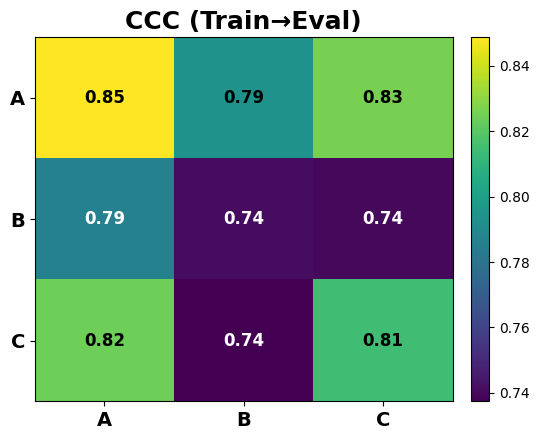

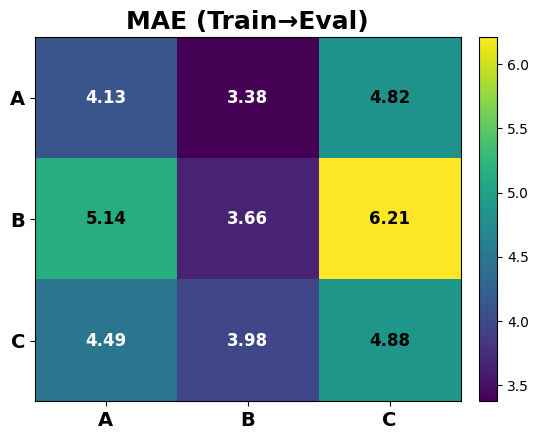

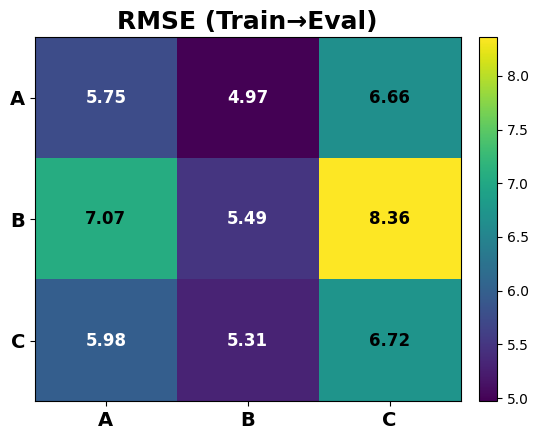

In [12]:
# %% [markdown]
# ## 6) Heatmaps

# %%
def heatmap(mat, title, fname):
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    im = ax.imshow(mat.values.astype(float), aspect='auto')
    # annotate
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ax.text(j, i, f"{mat.iloc[i,j]:.2f}", ha='center', va='center',
                    fontsize=12, fontweight='bold', color='white' if mat.iloc[i,j] < np.nanmean(mat.values) else 'black')
    # ticks
    ax.set_xticks(range(len(mat.columns)))
    ax.set_yticks(range(len(mat.index)))
    ax.set_xticklabels(mat.columns, fontsize=14, fontweight='bold')
    ax.set_yticklabels(mat.index, fontsize=14, fontweight='bold')
    # titles
    ax.set_title(title, fontsize=18, fontweight='bold')
    ax.grid(False)
    fig.colorbar(im, fraction=0.046, pad=0.04)
    fig.tight_layout()
    fig.savefig(DIR_CROSS / fname, dpi=200)
    plt.show()

heatmap(mat_CCC,  "CCC (Train→Eval)",  "cross_heatmap_CCC.png")
heatmap(mat_MAE,  "MAE (Train→Eval)",  "cross_heatmap_MAE.png")
heatmap(mat_RMSE, "RMSE (Train→Eval)", "cross_heatmap_RMSE.png")


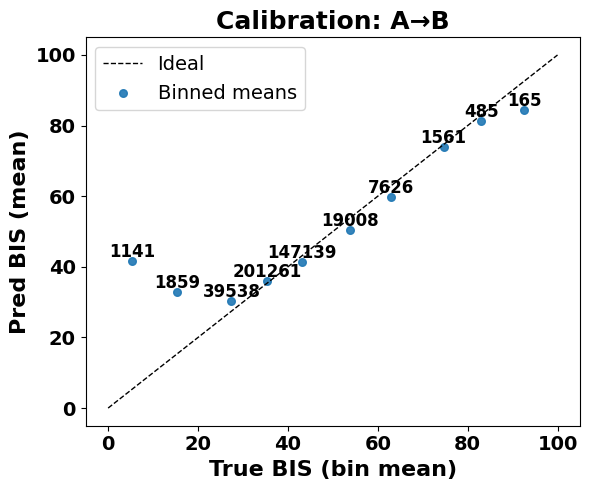

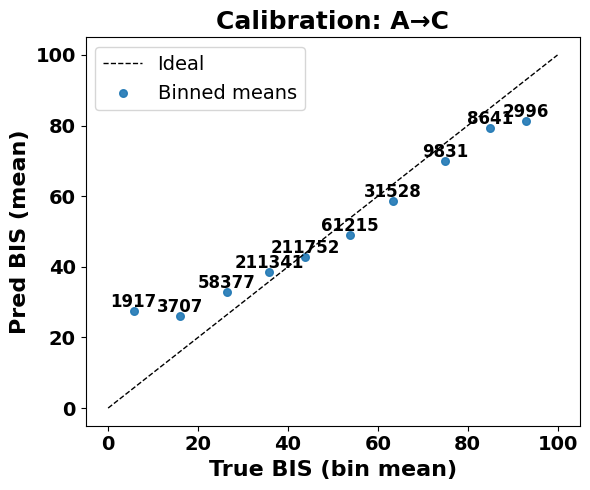

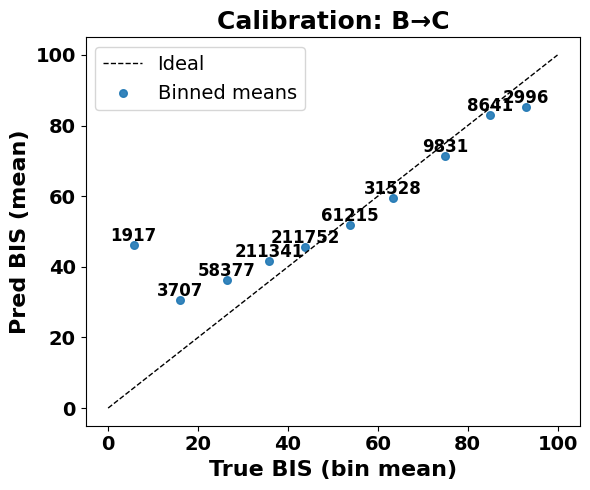

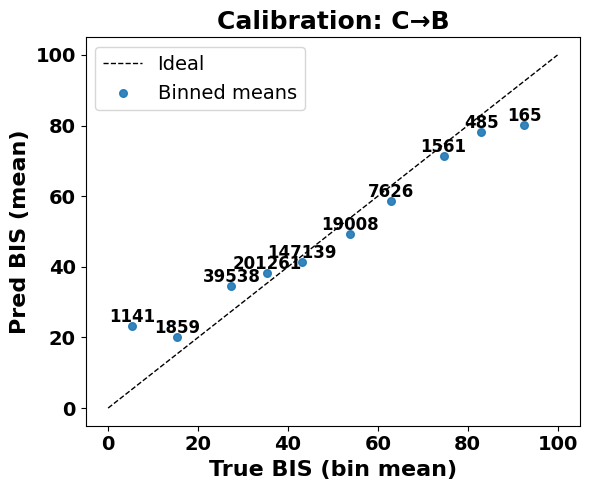

In [13]:
# %% [markdown]
# ## 7) Optional calibration plots for key pairs

# %%
def calibration_plot(y_true, y_pred, title, fname):
    bins = np.linspace(0, 100, 11)
    ids = np.digitize(y_true, bins) - 1
    pts = []
    for b in range(len(bins)-1):
        m = (ids == b)
        if m.sum() >= 20:
            pts.append((np.mean(y_true[m]), np.mean(y_pred[m]), m.sum()))
    pts = np.array(pts) if len(pts) else np.empty((0,3))
    fig, ax = plt.subplots(figsize=(6,5))
    ax.plot([0,100],[0,100],'k--',lw=1, label='Ideal')
    if len(pts):
        ax.scatter(pts[:,0], pts[:,1], s=30, alpha=0.9, label='Binned means')
        for xt, yp, n in pts: ax.text(xt, yp, f"{int(n)}", fontsize=12, fontweight='bold', ha='center', va='bottom')
    ax.set_title(title, fontsize=18, fontweight='bold')
    ax.set_xlabel("True BIS (bin mean)", fontsize=16, fontweight='bold')
    ax.set_ylabel("Pred BIS (mean)", fontsize=16, fontweight='bold')
    ax.tick_params(labelsize=14); 
    for lab in ax.get_xticklabels() + ax.get_yticklabels(): lab.set_fontweight('bold')
    ax.legend(fontsize=14); ax.grid(False); fig.tight_layout()
    fig.savefig(DIR_CROSS / fname, dpi=200); plt.show()

# Example pairs to visualize:
pairs = [("A","B"), ("A","C"), ("B","C"), ("C","B")]
for tr, ev in pairs:
    # load the saved pair preds (CSV.gz if Parquet not available)
    parq = DIR_CROSS / f"preds_{tr}_to_{ev}.parquet"
    csvg = DIR_CROSS / f"preds_{tr}_to_{ev}.csv.gz"
    if parq.exists():
        dfp = pd.read_parquet(parq)
    else:
        dfp = pd.read_csv(csvg)
    calibration_plot(dfp["y_true"].values, dfp["y_pred"].values,
                     title=f"Calibration: {tr}→{ev}", fname=f"calib_{tr}_to_{ev}.png")


In [14]:
# %% [markdown]
# ## X) Complexity–performance measurement (batch=1, 10s window)

# %%
import time, math, io, gc, numpy as np, torch
import pandas as pd

# -------------------
# config
# -------------------
MODEL_NAME = "LightUNet_SE_ConvMem (base)"  # change per variant
SEQ_LEN = 1280  # 10 s @128 Hz
BATCH = 1
WARMUP = 50
ITERS  = 300

# choose a representative input
x_cpu = torch.randn(BATCH, 1, SEQ_LEN, dtype=torch.float32)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# If you already have a loaded model, reuse it; otherwise instantiate:
try:
    model
except NameError:
    model = LightUNet_SE_ConvLSTM(input_channels=1, dropout_prob=0.2)

# Ensure eval/inference mode
model.eval()
for p in model.parameters(): p.requires_grad_(False)

# -------------------
# helpers
# -------------------
def count_params(m):
    total = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    return total, trainable

def state_dict_size_mb(m):
    buf = io.BytesIO()
    torch.save(m.state_dict(), buf)
    return len(buf.getvalue()) / (1024**2)

@torch.inference_mode()
def latency_ms(m, x, use_amp=False):
    # returns mean & p95 latency in milliseconds
    if x.device.type == "cuda":
        torch.cuda.synchronize()
    times = []
    for i in range(WARMUP + ITERS):
        t0 = time.perf_counter()
        if use_amp and x.device.type == "cuda":
            with torch.cuda.amp.autocast():
                _ = m(x)
        else:
            _ = m(x)
        if x.device.type == "cuda":
            torch.cuda.synchronize()
        if i >= WARMUP:
            times.append((time.perf_counter() - t0) * 1000.0)
    return float(np.mean(times)), float(np.percentile(times, 95))

@torch.inference_mode()
def peak_gpu_mem_mb(m, x):
    if x.device.type != "cuda":
        return None
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    _ = m(x)
    torch.cuda.synchronize()
    peak = torch.cuda.max_memory_allocated() / (1024**2)
    return float(peak)

def jit_trace(m, sample):
    # TorchScript (may speed CPU a bit)
    m = m.cpu().eval()
    with torch.inference_mode():
        ts = torch.jit.trace(m, sample)
        ts = torch.jit.optimize_for_inference(ts)
    return ts

def try_flops_with_thop(m, sample):
    # Optional FLOPs (install thop: pip install thop)
    try:
        from thop import profile
        macs, _ = profile(m, inputs=(sample,), verbose=False)
        # Some papers report GMACs; others report GFLOPs ≈ 2*GMACs
        gmacs = macs / 1e9
        gflops = 2 * gmacs
        return float(gmacs), float(gflops)
    except Exception as e:
        return None, None

# -------------------
# 1) Parameters & model size
# -------------------
params_total, params_train = count_params(model)
size_mb = state_dict_size_mb(model)

# -------------------
# 2) FLOPs / MACs (optional)
# -------------------
gmacs, gflops = try_flops_with_thop(model.cpu(), x_cpu)

# -------------------
# 3) Latency & memory
# -------------------
# CPU (FP32)
torch.set_num_threads(max(1, torch.get_num_threads()))  # keep current setting
m_cpu = model.cpu()
mean_cpu, p95_cpu = latency_ms(m_cpu, x_cpu, use_amp=False)

# TorchScript CPU (optional)
try:
    ts_model = jit_trace(model, x_cpu)
    mean_ts, p95_ts = latency_ms(ts_model, x_cpu, use_amp=False)
except Exception:
    mean_ts = p95_ts = None

# GPU (if available)
if torch.cuda.is_available():
    m_gpu = model.to(device)
    x_gpu = x_cpu.to(device, non_blocking=True)
    mean_gpu, p95_gpu = latency_ms(m_gpu, x_gpu, use_amp=False)         # FP32
    mean_gpu16, p95_gpu16 = latency_ms(m_gpu, x_gpu, use_amp=True)      # AMP FP16
    peak_mb = peak_gpu_mem_mb(m_gpu, x_gpu)
    # cleanup
    del x_gpu; gc.collect(); torch.cuda.empty_cache()
else:
    mean_gpu = p95_gpu = mean_gpu16 = p95_gpu16 = peak_mb = None

# -------------------
# 4) Collect & show
# -------------------
row = {
    "Model": MODEL_NAME,
    "Params (M)": round(params_total / 1e6, 3),
    "StateDict (MB)": round(size_mb, 2),
    "GMACs / window": (None if gmacs is None else round(gmacs, 3)),
    "GFLOPs / window": (None if gflops is None else round(gflops, 3)),
    "CPU FP32 mean (ms)": round(mean_cpu, 2),
    "CPU FP32 p95 (ms)": round(p95_cpu, 2),
    "CPU TorchScript mean (ms)": (None if mean_ts is None else round(mean_ts, 2)),
    "CPU TorchScript p95 (ms)": (None if p95_ts is None else round(p95_ts, 2)),
    "GPU FP32 mean (ms)": (None if mean_gpu is None else round(mean_gpu, 2)),
    "GPU FP32 p95 (ms)": (None if p95_gpu is None else round(p95_gpu, 2)),
    "GPU AMP FP16 mean (ms)": (None if mean_gpu16 is None else round(mean_gpu16, 2)),
    "GPU AMP FP16 p95 (ms)": (None if p95_gpu16 is None else round(p95_gpu16, 2)),
    "Peak GPU Mem (MB)": (None if peak_mb is None else round(peak_mb, 1)),
}
df_complexity = pd.DataFrame([row])
display(df_complexity)

# Optionally append to a CSV you’ll collect for all variants:
OUT = Path("project") / "metrics" / "complexity_summary.csv"
OUT.parent.mkdir(parents=True, exist_ok=True)
if OUT.exists():
    old = pd.read_csv(OUT)
    # avoid duplicate rows for same model name
    old = old[old["Model"] != MODEL_NAME]
    df_out = pd.concat([old, df_complexity], ignore_index=True)
else:
    df_out = df_complexity.copy()
df_out.to_csv(OUT, index=False)
print("Saved complexity summary →", OUT)


/tmp/ipykernel_862984/1834381153.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


,Model,Params (M),StateDict (MB),GMACs / window,GFLOPs / window,CPU FP32 mean (ms),CPU FP32 p95 (ms),CPU TorchScript mean (ms),CPU TorchScript p95 (ms),GPU FP32 mean (ms),GPU FP32 p95 (ms),GPU AMP FP16 mean (ms),GPU AMP FP16 p95 (ms),Peak GPU Mem (MB)
0,LightUNet_SE_ConvMem (base),0.272,1.08,None,None,8.33,10.33,5.36,6.4,4.04,5.09,4.97,6.62,11.8


Saved complexity summary → project/metrics/complexity_summary.csv


In [1]:
import pandas as pd
from pathlib import Path

ROOT = Path("project")
DIR_METRICS = ROOT / "metrics"

def row(cohort):
    m = pd.read_csv(DIR_METRICS / f"metrics_{cohort}_test.csv").iloc[0]
    return {
        "Cohort": cohort,
        "N_subjects": int(m["N_subjects"]),
        "N_segments": int(m["N_segments"]),
        "MAE": round(m["global_clip_MAE"], 3),
        "RMSE": round(m["global_clip_RMSE"], 3),
        "CCC": round(m["global_clip_CCC"], 3),
        "Pearson_r": round(m["global_clip_Pearson_r"], 3),
        "R2": round(m["global_clip_R2"], 3),
        "±5%": round(m["global_clip_Acc_5"], 1),
        "±10%": round(m["global_clip_Acc_10"], 1),
    }

tbl = pd.DataFrame([row("A"), row("B"), row("C")])
print(tbl.to_string(index=False))


Cohort  N_subjects  N_segments   MAE  RMSE   CCC  Pearson_r    R2  ±5%  ±10%
     A         146      526618 4.127 5.753 0.849      0.854 0.727 69.6  92.5
     B         105      419783 3.662 5.492 0.741      0.758 0.542 76.6  95.0
     C         153      601305 4.879 6.720 0.815      0.837 0.698 62.1  88.8


In [2]:
import pandas as pd
from pathlib import Path

ROOT = Path("project")
DIR_CROSS = ROOT / "cross"

mat_CCC  = pd.read_csv(DIR_CROSS / "cross_CCC.csv", index_col=0)
mat_MAE  = pd.read_csv(DIR_CROSS / "cross_MAE.csv", index_col=0)
mat_RMSE = pd.read_csv(DIR_CROSS / "cross_RMSE.csv", index_col=0)

print("\nCCC (Train → Eval)\n", mat_CCC.round(3).to_string())
print("\nMAE (↓)\n",          mat_MAE.round(3).to_string())
print("\nRMSE (↓)\n",         mat_RMSE.round(3).to_string())

# Optional deltas (off-diagonal minus diagonal of target eval)
try:
    dCCC  = pd.read_csv(DIR_CROSS / "cross_delta_CCC.csv",  index_col=0).round(3)
    dMAE  = pd.read_csv(DIR_CROSS / "cross_delta_MAE.csv",  index_col=0).round(3)
    dRMSE = pd.read_csv(DIR_CROSS / "cross_delta_RMSE.csv", index_col=0).round(3)
    print("\nΔCCC vs in-domain (neg = worse)\n",  dCCC.to_string())
    print("\nΔMAE vs in-domain (pos = worse)\n",  dMAE.to_string())
    print("\nΔRMSE vs in-domain (pos = worse)\n", dRMSE.to_string())
except FileNotFoundError:
    pass



CCC (Train → Eval)
        A      B      C
A  0.849  0.794  0.826
B  0.786  0.741  0.740
C  0.824  0.737  0.815

MAE (↓)
        A      B      C
A  4.127  3.376  4.815
B  5.136  3.662  6.209
C  4.493  3.981  4.879

RMSE (↓)
        A      B      C
A  5.753  4.970  6.657
B  7.073  5.492  8.359
C  5.981  5.306  6.720

ΔCCC vs in-domain (neg = worse)
        B      C      A
A  0.053  0.011  0.000
B  0.000 -0.075 -0.062
C -0.004  0.000 -0.024

ΔMAE vs in-domain (pos = worse)
        B      C      A
A -0.286 -0.063  0.000
B  0.000  1.330  1.009
C  0.319  0.000  0.366

ΔRMSE vs in-domain (pos = worse)
        B      C      A
A -0.522 -0.063  0.000
B  0.000  1.639  1.319
C -0.186  0.000  0.227


In [3]:
# In-domain calibration & Bland–Altman numeric summary (A/B/C)
import numpy as np, pandas as pd
from pathlib import Path

ROOT       = Path("project")
DIR_PREDS  = ROOT / "preds"     # adjust if different (where preds_{A|B|C}_test.* were saved)

def _read_preds(base, cohort):
    parq = base / f"preds_{cohort}_test.parquet"
    csvg = base / f"preds_{cohort}_test.csv.gz"
    if parq.exists():
        df = pd.read_parquet(parq)
    else:
        df = pd.read_csv(csvg)
    return df["y_true"].values.astype(float), df["y_pred"].values.astype(float)

def _calib_ba(y_true, y_pred):
    # calibration (unbinned) slope/intercept: y_pred ≈ a + b * y_true
    b, a = np.polyfit(y_true, y_pred, 1)
    # Bland–Altman
    diff = y_pred - y_true
    bias = float(np.mean(diff))
    sd   = float(np.std(diff, ddof=1))
    loa_l = bias - 1.96*sd
    loa_u = bias + 1.96*sd
    return dict(intercept=a, slope=b, bias=bias, sd=sd, loa_lower=loa_l, loa_upper=loa_u)

rows = []
for coh in ["A","B","C"]:
    yt, yp = _read_preds(DIR_PREDS, coh)
    rows.append({"Cohort": coh, **_calib_ba(yt, yp)})

df_ba = pd.DataFrame(rows)
# round for display
df_ba_round = df_ba.copy()
for col in df_ba.columns:
    if col != "Cohort":
        df_ba_round[col] = df_ba_round[col].map(lambda v: f"{v:.3f}")

print(df_ba_round.to_string(index=False))

# LaTeX table to paste
print("\n% ---- LaTeX ----")
print(df_ba_round.to_latex(index=False,
                           caption="In-domain calibration (slope/intercept) and Bland--Altman statistics.",
                           label="tab:calib_ba_indomain",
                           column_format="lrrrrrr"))


Cohort intercept slope  bias    sd loa_lower loa_upper
     A     9.794 0.766 0.197 5.750   -11.073    11.467
     B    14.570 0.655 1.191 5.361    -9.318    11.699
     C    14.379 0.663 0.108 6.719   -13.062    13.278

% ---- LaTeX ----
\begin{table}
\caption{In-domain calibration (slope/intercept) and Bland--Altman statistics.}
\label{tab:calib_ba_indomain}
\begin{tabular}{lrrrrrr}
\toprule
Cohort & intercept & slope & bias & sd & loa_lower & loa_upper \\
\midrule
A & 9.794 & 0.766 & 0.197 & 5.750 & -11.073 & 11.467 \\
B & 14.570 & 0.655 & 1.191 & 5.361 & -9.318 & 11.699 \\
C & 14.379 & 0.663 & 0.108 & 6.719 & -13.062 & 13.278 \\
\bottomrule
\end{tabular}
\end{table}



In [4]:
# Cross-pair calibration & Bland–Altman (A→B, A→C, B→C, C→B, etc.)
DIR_CROSS = ROOT / "cross"

pairs = [("A","B"), ("A","C"), ("B","A"), ("B","C"), ("C","A"), ("C","B")]
def _read_pair(tr, ev):
    parq = DIR_CROSS / f"preds_{tr}_to_{ev}.parquet"
    csvg = DIR_CROSS / f"preds_{tr}_to_{ev}.csv.gz"
    if parq.exists():
        df = pd.read_parquet(parq)
    else:
        df = pd.read_csv(csvg)
    return df["y_true"].values.astype(float), df["y_pred"].values.astype(float)

rows = []
for tr, ev in pairs:
    yt, yp = _read_pair(tr, ev)
    stats = _calib_ba(yt, yp)
    rows.append({"Train": tr, "Eval": ev, **stats})

df_cross = pd.DataFrame(rows)
df_cross_round = df_cross.copy()
for col in df_cross.columns:
    if col not in ["Train","Eval"]:
        df_cross_round[col] = df_cross_round[col].map(lambda v: f"{v:.3f}")
print(df_cross_round.to_string(index=False))

print("\n% ---- LaTeX ----")
print(df_cross_round.to_latex(index=False,
                              caption="Cross-cohort calibration (slope/intercept) and Bland--Altman statistics.",
                              label="tab:calib_ba_cross",
                              column_format="llrrrrrr"))


Train Eval intercept slope   bias    sd loa_lower loa_upper
    A    B    10.567 0.724 -0.139 4.968    -9.877     9.599
    A    C    13.032 0.702  0.376 6.646   -12.651    13.402
    B    A    12.376 0.759  2.523 6.607   -10.427    15.474
    B    C    17.600 0.664  3.350 7.658   -11.660    18.361
    C    A    13.210 0.692  0.593 5.951   -11.071    12.257
    C    B    16.674 0.600  1.160 5.178    -8.988    11.308

% ---- LaTeX ----
\begin{table}
\caption{Cross-cohort calibration (slope/intercept) and Bland--Altman statistics.}
\label{tab:calib_ba_cross}
\begin{tabular}{llrrrrrr}
\toprule
Train & Eval & intercept & slope & bias & sd & loa_lower & loa_upper \\
\midrule
A & B & 10.567 & 0.724 & -0.139 & 4.968 & -9.877 & 9.599 \\
A & C & 13.032 & 0.702 & 0.376 & 6.646 & -12.651 & 13.402 \\
B & A & 12.376 & 0.759 & 2.523 & 6.607 & -10.427 & 15.474 \\
B & C & 17.600 & 0.664 & 3.350 & 7.658 & -11.660 & 18.361 \\
C & A & 13.210 & 0.692 & 0.593 & 5.951 & -11.071 & 12.257 \\
C & B & 16.674 & 

In [9]:
# %% [markdown]
# ### Complexity probe (params, MACs, size, latency, VRAM)

import io, time, json, math, torch, numpy as np, pandas as pd
from pathlib import Path

# --- your two models (import from your notebook/notebook scope) ---
# from your_code import UNet1D_BiLSTM, LightUNet_SE_ConvLSTM
# (they are already defined in your training notebook)

def count_params(model):
    return sum(p.numel() for p in model.parameters())

def model_size_mb(model):
    buf = io.BytesIO()
    torch.save(model.state_dict(), buf)
    return len(buf.getbuffer()) / (1024**2)

def try_import_thop():
    try:
        import thop
        return thop
    except Exception:
        return None

def macs_for_1d(model, T=1280, B=1, device="cuda"):
    # use THOP if available; otherwise return NaN
    thop = try_import_thop()
    if thop is None:
        return float("nan")
    x = torch.randn(B, 1, T, device=device)
    model = model.to(device).eval()
    with torch.no_grad():
        macs, params = thop.profile(model, inputs=(x,), verbose=False)
    # thop returns MACs (multiply-adds). Convert to G MACs.
    return macs / 1e9

@torch.no_grad()
def latency_ms(model, device="cuda", T=1280, B=1, warmup=30, iters=100):
    x = torch.randn(B, 1, T, device=device)
    model = model.to(device).eval()
    # warmup
    for _ in range(warmup):
        _ = model(x)
    times = []
    if device == "cuda" and torch.cuda.is_available():
        torch.cuda.synchronize()
        t0 = time.perf_counter()
        for _ in range(iters):
            _ = model(x)
        torch.cuda.synchronize()
        t1 = time.perf_counter()
    else:
        t0 = time.perf_counter()
        for _ in range(iters):
            _ = model(x)
        t1 = time.perf_counter()
    return 1000.0 * (t1 - t0) / iters

def peak_vram_mb(model, T=1280, B=1):
    if not torch.cuda.is_available():
        return float("nan")
    device = "cuda"
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    x = torch.randn(B, 1, T, device=device)
    model = model.to(device).eval()
    with torch.no_grad():
        _ = model(x)
    peak = torch.cuda.max_memory_allocated()
    return peak / (1024**2)

def hardware_row():
    gpu = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only"
    return {
        "torch": torch.__version__,
        "cuda": torch.version.cuda if torch.cuda.is_available() else "none",
        "cudnn": torch.backends.cudnn.version() if torch.cuda.is_available() else "none",
        "gpu": gpu,
        "cpu_threads": torch.get_num_threads(),
    }

# --- measure both models ---
models = [
    ("LightUNet_SE_ConvLSTM", LightUNet_SE_ConvLSTM(input_channels=1, dropout_prob=0.2)),
]

rows = []
for name, mdl in models:
    row = {"model": name}
    row["params_M"]     = count_params(mdl) / 1e6
    row["size_MB"]      = model_size_mb(mdl)
    # MACs/latency on GPU if available; fall back to CPU
    dev = "cuda" if torch.cuda.is_available() else "cpu"
    row["macs_G@T1280"] = macs_for_1d(mdl, T=1280, B=1, device=dev)
    row["lat_ms_gpu@B1"] = latency_ms(mdl, device=dev, T=1280, B=1)
    row["lat_ms_gpu@B32"] = latency_ms(mdl, device=dev, T=1280, B=32)
    row["vram_MB@B32"]   = peak_vram_mb(mdl, T=1280, B=32)
    # CPU latency as well
    row["lat_ms_cpu@B1"]  = latency_ms(mdl, device="cpu", T=1280, B=1)
    row["lat_ms_cpu@B32"] = latency_ms(mdl, device="cpu", T=1280, B=32)
    rows.append(row)

df = pd.DataFrame(rows)
ROOT = Path("project"); (ROOT / "complexity").mkdir(parents=True, exist_ok=True)
df.to_csv(ROOT / "complexity" / "complexity.csv", index=False)

# also record environment for the paper appendix
with open(ROOT / "complexity" / "env.json", "w") as f:
    json.dump(hardware_row(), f, indent=2)

print(df.round(3).to_string(index=False))
print("Saved →", ROOT / "complexity" / "complexity.csv", "| env →", ROOT / "complexity" / "env.json")


                model  params_M  size_MB  macs_G@T1280  lat_ms_gpu@B1  lat_ms_gpu@B32  vram_MB@B32  lat_ms_cpu@B1  lat_ms_cpu@B32
LightUNet_SE_ConvLSTM     0.272    1.079           NaN          4.428           4.345       54.492         10.315          37.618
Saved → project\complexity\complexity.csv | env → project\complexity\env.json


In [10]:
# %% [markdown]
# ### Summarize performance across A/B/C (avg + worst-case)

import pandas as pd
from pathlib import Path

ROOT = Path("project")
mA = pd.read_csv(ROOT / "metrics" / "metrics_A_test.csv").iloc[0]
mB = pd.read_csv(ROOT / "metrics" / "metrics_B_test.csv").iloc[0]
mC = pd.read_csv(ROOT / "metrics" / "metrics_C_test.csv").iloc[0]

def pick(m, key): return float(m[f"global_clip_{key}"])  # MAE, RMSE, CCC, Acc_10
CCC  = [pick(mA,"CCC"), pick(mB,"CCC"), pick(mC,"CCC")]
MAE  = [pick(mA,"MAE"), pick(mB,"MAE"), pick(mC,"MAE")]
ACC10= [pick(mA,"Acc_10"), pick(mB,"Acc_10"), pick(mC,"Acc_10")]

summary = pd.DataFrame({
    "metric": ["CCC","MAE","±10 acc"],
    "avg":    [sum(CCC)/3, sum(MAE)/3, sum(ACC10)/3],
    "worst":  [min(CCC),   max(MAE),   min(ACC10)],
}).round(3)
print(summary.to_string(index=False))
summary.to_csv(ROOT / "complexity" / "perf_summary.csv", index=False)


 metric    avg  worst
    CCC  0.802  0.741
    MAE  4.222  4.879
±10 acc 92.093 88.816


In [11]:
!pip install thop torchinfo



   ---------------------------------------- 2/2 [thop]



In [17]:
# --- EDIT THIS LINE to your project folder ---
PROJECT_ROOT_STR = r"C:\Users\RAZER\Documents\GitHub_2\NYC_Research_Cell\BIS\LINUX_MACHINE\project"

# No edits below
from pathlib import Path
import os, math, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path(PROJECT_ROOT_STR)
DIR_PREDS   = PROJECT_ROOT / "preds"
DIR_METRICS = PROJECT_ROOT / "metrics"
DIR_FIGS    = PROJECT_ROOT / "figures"
DIR_CROSS   = PROJECT_ROOT / "cross"
DIR_SPLITS  = PROJECT_ROOT / "splits"  # optional

for d in [DIR_PREDS, DIR_METRICS, DIR_FIGS, DIR_CROSS]:
    d.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT.resolve())
print("Preds dir:   ", DIR_PREDS.resolve())
print("Splits dir:  ", DIR_SPLITS.resolve(), "(exists:", DIR_SPLITS.exists(), ")")

COHORTS = ["A","B","C"]
SRATE = 128
SEG_STRIDE_SEC = 2.0  # you extracted a new window every 2 s


Project root: C:\Users\RAZER\Documents\GitHub_2\NYC_Research_Cell\BIS\LINUX_MACHINE\project
Preds dir:    C:\Users\RAZER\Documents\GitHub_2\NYC_Research_Cell\BIS\LINUX_MACHINE\project\preds
Splits dir:   C:\Users\RAZER\Documents\GitHub_2\NYC_Research_Cell\BIS\LINUX_MACHINE\project\splits (exists: True )


In [18]:
def read_preds(cohort, split="test"):
    p_parq = DIR_PREDS / f"preds_{cohort}_{split}.parquet"
    p_csvg = DIR_PREDS / f"preds_{cohort}_{split}.csv.gz"
    if p_parq.exists():
        return pd.read_parquet(p_parq)
    if p_csvg.exists():
        return pd.read_csv(p_csvg, compression="gzip")
    return None

def concordance_ccc(y_true, y_pred):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    mu1, mu2 = y_true.mean(), y_pred.mean()
    v1, v2 = y_true.var(ddof=1), y_pred.var(ddof=1)
    cov = np.mean((y_true - mu1)*(y_pred - mu2))
    return (2*cov) / (v1 + v2 + (mu1 - mu2)**2 + 1e-12)

def metric_bundle(y_t, y_p):
    y_t, y_p = np.asarray(y_t), np.asarray(y_p)
    mae  = np.mean(np.abs(y_t - y_p))
    rmse = math.sqrt(np.mean((y_t - y_p)**2))
    ccc  = concordance_ccc(y_t, y_p)
    acc5  = np.mean(np.abs(y_t - y_p) <= 5) * 100
    acc10 = np.mean(np.abs(y_t - y_p) <= 10) * 100
    return dict(CCC=ccc, MAE=mae, RMSE=rmse, Acc_10=acc10, Acc_5=acc5)


In [19]:
from sklearn.linear_model import LinearRegression

def fit_affine(y_true, y_pred):
    reg = LinearRegression().fit(y_pred.reshape(-1,1), y_true.reshape(-1,1))
    beta  = float(reg.coef_.ravel()[0])
    alpha = float(reg.intercept_.ravel()[0])
    return alpha, beta

def apply_affine(y_pred, alpha, beta):
    return alpha + beta * y_pred

def eval_recalibration_for(cohort):
    df_test = read_preds(cohort, "test")
    if df_test is None or df_test.empty:
        raise FileNotFoundError(f"Missing predictions for {cohort} test at {DIR_PREDS} (preds_{cohort}_test.*)")

    # Preferred: use saved val predictions if available
    df_val = read_preds(cohort, "val")
    if df_val is not None and not df_val.empty:
        mode = "val"
        alpha, beta = fit_affine(df_val["y_true"].values, df_val["y_pred"].values)
        y_after = apply_affine(df_test["y_pred"].values, alpha, beta)
    else:
        # Safe fallback: subject-wise 2-fold calibration on TEST (no subject leakage)
        mode = "cv2fold"
        subs = np.array(sorted(df_test["caseid"].unique()))
        rng = np.random.default_rng(42); rng.shuffle(subs)
        mid = len(subs)//2
        folds = [subs[:mid], subs[mid:]]
        df_test = df_test.sort_values(["caseid","seg_idx"]).reset_index(drop=True)
        y_after = np.empty(len(df_test))
        for k in range(2):
            cal_subj = set(folds[k]); evl_subj = set(folds[1-k])
            cal_m = df_test["caseid"].isin(cal_subj)
            evl_m = df_test["caseid"].isin(evl_subj)
            a, b = fit_affine(df_test.loc[cal_m,"y_true"].values,
                              df_test.loc[cal_m,"y_pred"].values)
            y_after[evl_m.values] = apply_affine(df_test.loc[evl_m,"y_pred"].values, a, b)
        alpha, beta = np.nan, np.nan  # many local fits; no single mapping

    before = metric_bundle(df_test["y_true"].values, df_test["y_pred"].values)
    after  = metric_bundle(df_test["y_true"].values, y_after)

    # Save per-sample calibrated preds for later smoothing
    out = df_test.copy()
    out["y_pred_cal"] = y_after
    out_path = DIR_PREDS / f"preds_{cohort}_test_calibrated.csv.gz"
    out.to_csv(out_path, index=False, compression="gzip")

    return before, after, dict(mode=mode, alpha=alpha, beta=beta), out_path

# Run A/B/C
rows = []
for coh in COHORTS:
    b, a, m, pth = eval_recalibration_for(coh)
    rows.append({
        "cohort": coh, "mode": m["mode"], "alpha": m["alpha"], "beta": m["beta"],
        "CCC_before": b["CCC"], "CCC_after": a["CCC"],
        "MAE_before": b["MAE"], "MAE_after": a["MAE"],
        "Acc10_before": b["Acc_10"], "Acc10_after": a["Acc_10"],
    })
df_recal = pd.DataFrame(rows).round(3)
df_recal.to_csv(DIR_METRICS / "recalib_effect.csv", index=False)
print(df_recal)
print("Saved →", DIR_METRICS / "recalib_effect.csv")


  cohort     mode  alpha  beta  CCC_before  CCC_after  MAE_before  MAE_after  \
0      A  cv2fold    NaN   NaN       0.849      0.842       4.127      4.138   
1      B  cv2fold    NaN   NaN       0.741      0.730       3.662      3.631   
2      C  cv2fold    NaN   NaN       0.815      0.824       4.879      4.843   

   Acc10_before  Acc10_after  
0        92.501       92.481  
1        94.962       95.798  
2        88.816       88.928  
Saved → C:\Users\RAZER\Documents\GitHub_2\NYC_Research_Cell\BIS\LINUX_MACHINE\project\metrics\recalib_effect.csv


In [20]:
def ema_smooth_seq(y, half_life_s, dt_s):
    if half_life_s == 0:
        return y.copy()
    tau = half_life_s / np.log(2)
    lam = 1 - np.exp(-dt_s / tau)
    out = np.empty_like(y, dtype=float)
    out[0] = y[0]
    for i in range(1, len(y)):
        out[i] = lam * y[i] + (1 - lam) * out[i-1]
    return out

def subjectwise_apply(df, y_col, half_life_s):
    ys = []
    for _, g in df.sort_values(["caseid","seg_idx"]).groupby("caseid", sort=False):
        y = g[y_col].values.astype(float)
        ys.append(ema_smooth_seq(y, half_life_s, SEG_STRIDE_SEC))
    return np.concatenate(ys)

def median_transition_lag_seconds(df, y_true_col, y_pred_col):
    # crude cross-correlation lag (step = 2 s)
    lags = []
    for _, g in df.sort_values(["caseid","seg_idx"]).groupby("caseid", sort=False):
        yt = g[y_true_col].values.astype(float)
        yp = g[y_pred_col].values.astype(float)
        if len(yt) < 5: continue
        c = np.correlate(yt - yt.mean(), yp - yp.mean(), mode="full")
        lag_idx = np.argmax(c) - (len(yt)-1)
        lags.append(lag_idx * SEG_STRIDE_SEC)
    return float(np.median(lags)) if lags else 0.0

def smoothing_ablation_for(cohort):
    p = DIR_PREDS / f"preds_{cohort}_test_calibrated.csv.gz"
    if not p.exists():
        raise FileNotFoundError(f"Run recalibration first (missing {p})")
    df = pd.read_csv(p).sort_values(["caseid","seg_idx"]).reset_index(drop=True)
    rows = []
    for h in [0, 2, 3, 5]:
        df["y_smooth"] = subjectwise_apply(df, "y_pred_cal", half_life_s=h)
        m = metric_bundle(df["y_true"].values, df["y_smooth"].values)
        lag = median_transition_lag_seconds(df, "y_true", "y_smooth")
        rows.append({"cohort": cohort, "half_life_s": h, **m, "Lag_s": lag})
    return pd.DataFrame(rows)

df_smooth = pd.concat([smoothing_ablation_for(c) for c in COHORTS], ignore_index=True).round(3)
df_smooth.to_csv(DIR_METRICS / "smoothing_ablation.csv", index=False)
print(df_smooth)
print("Saved →", DIR_METRICS / "smoothing_ablation.csv")


   cohort  half_life_s    CCC    MAE   RMSE  Acc_10   Acc_5  Lag_s
0       A            0  0.842  4.138  5.742  92.481  69.589    6.0
1       A            2  0.862  3.852  5.325  93.887  72.500    4.0
2       A            3  0.869  3.733  5.156  94.436  73.709    4.0
3       A            5  0.878  3.599  4.957  95.068  75.076    4.0
4       B            0  0.730  3.631  5.296  95.798  76.527    6.0
5       B            2  0.749  3.444  5.063  96.386  78.986    4.0
6       B            3  0.756  3.369  4.967  96.628  80.004    4.0
7       B            5  0.764  3.288  4.860  96.859  81.190    4.0
8       C            0  0.824  4.843  6.698  88.928  62.601    6.0
9       C            2  0.844  4.505  6.240  90.891  65.700    6.0
10      C            3  0.852  4.363  6.048  91.725  67.082    4.0
11      C            5  0.862  4.197  5.815  92.660  68.726    4.0
Saved → C:\Users\RAZER\Documents\GitHub_2\NYC_Research_Cell\BIS\LINUX_MACHINE\project\metrics\smoothing_ablation.csv


C:\Users\RAZER\AppData\Local\Temp\ipykernel_7596\2203048694.py:26: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\RAZER\AppData\Local\Temp\ipykernel_7596\2203048694.py:28: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(outp, dpi=200)
c:\Users\RAZER\miniconda3\envs\torch_on\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


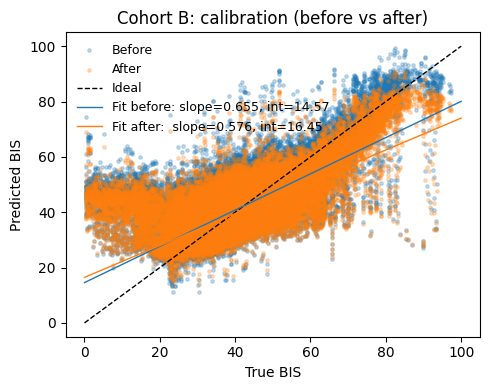

Saved → C:\Users\RAZER\Documents\GitHub_2\NYC_Research_Cell\BIS\LINUX_MACHINE\project\cross\calib_B_before_after.png


In [21]:
coh = "B"
df_raw = read_preds(coh, "test").sort_values(["caseid","seg_idx"]).reset_index(drop=True)
df_cal = pd.read_csv(DIR_PREDS / f"preds_{coh}_test_calibrated.csv.gz").sort_values(["caseid","seg_idx"]).reset_index(drop=True)

y_true = df_raw["y_true"].values
y_raw  = df_raw["y_pred"].values
y_cal  = df_cal["y_pred_cal"].values

def fit_line(x, y):
    c = np.polyfit(x, y, 1)
    return c[0], c[1]

s0, i0 = fit_line(y_true, y_raw)
s1, i1 = fit_line(y_true, y_cal)

plt.figure(figsize=(5.0,4.0))
plt.scatter(y_true, y_raw, s=6, alpha=0.25, label="Before")
plt.scatter(y_true, y_cal, s=6, alpha=0.25, label="After")
xx = np.linspace(0,100,200)
plt.plot(xx, xx, 'k--', lw=1, label="Ideal")
plt.plot(xx, s0*xx + i0, lw=1, label=f"Fit before: slope={s0:.3f}, int={i0:.2f}")
plt.plot(xx, s1*xx + i1, lw=1, label=f"Fit after:  slope={s1:.3f}, int={i1:.2f}")
plt.xlabel("True BIS"); plt.ylabel("Predicted BIS")
plt.title("Cohort B: calibration (before vs after)")
plt.legend(frameon=False, fontsize=9)
plt.tight_layout()
outp = DIR_CROSS / "calib_B_before_after.png"
plt.savefig(outp, dpi=200)
plt.show()
print("Saved →", outp)


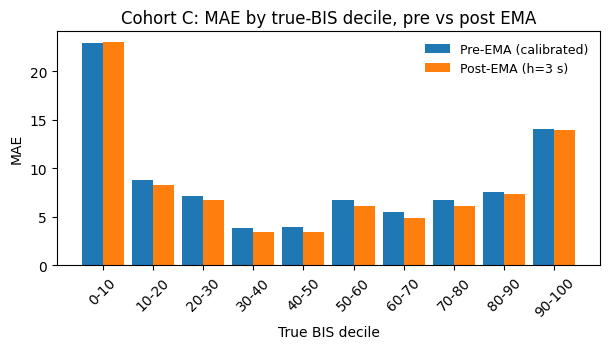

Saved → C:\Users\RAZER\Documents\GitHub_2\NYC_Research_Cell\BIS\LINUX_MACHINE\project\figures\error_vs_truebin_C_before_after.png


In [22]:
coh = "C"
df = pd.read_csv(DIR_PREDS / f"preds_{coh}_test_calibrated.csv.gz").sort_values(["caseid","seg_idx"]).reset_index(drop=True)

# smooth with h=3 s
def ema_series(df_in, h):
    tau = h / np.log(2)
    lam = 1 - np.exp(-SEG_STRIDE_SEC / tau)
    ys = []
    for _, g in df_in.groupby("caseid", sort=False):
        y = g["y_pred_cal"].values.astype(float)
        out = np.empty_like(y); out[0] = y[0]
        for i in range(1,len(y)): out[i] = lam*y[i] + (1-lam)*out[i-1]
        ys.append(out)
    return np.concatenate(ys)

df["y_ema3"] = ema_series(df, 3)

bins = np.linspace(0,100,11)
bid  = np.digitize(df["y_true"].values, bins) - 1
mae_pre, mae_post, labels = [], [], []
for b in range(len(bins)-1):
    m = (bid == b)
    if m.sum() == 0: continue
    mae_pre.append(np.mean(np.abs(df["y_true"].values[m] - df["y_pred_cal"].values[m])))
    mae_post.append(np.mean(np.abs(df["y_true"].values[m] - df["y_ema3"].values[m])))
    labels.append(f"{int(bins[b])}-{int(bins[b+1])}")

x = np.arange(len(labels)); w = 0.42
plt.figure(figsize=(6.2,3.6))
plt.bar(x - w/2, mae_pre,  width=w, label="Pre-EMA (calibrated)")
plt.bar(x + w/2, mae_post, width=w, label="Post-EMA (h=3 s)")
plt.xticks(x, labels, rotation=45)
plt.ylabel("MAE"); plt.xlabel("True BIS decile")
plt.title("Cohort C: MAE by true-BIS decile, pre vs post EMA")
plt.legend(frameon=False, fontsize=9)
plt.tight_layout()
outp = DIR_FIGS / "error_vs_truebin_C_before_after.png"
plt.savefig(outp, dpi=200)
plt.show()
print("Saved →", outp)
